In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("happy_merged.csv", skiprows=15)

print(df.head())

          Date/Time  100m_N Avg [m/s]  100m_S Avg [m/s]  80m Avg [m/s]  \
0  01-12-2018 00:00            10.654            10.809          5.182   
1  01-12-2018 00:10            10.531            10.688          5.334   
2  01-12-2018 00:20             9.976            10.110          5.319   
3  01-12-2018 00:30             9.617             9.735          5.319   
4  01-12-2018 00:40             9.001             9.112          5.363   

   50m Avg [m/s]  20m Avg [m/s]  10m Avg [m/s]  Pressure 5m [mbar]  \
0          7.096          4.852            NaN              1012.2   
1          7.415          4.953            NaN              1012.1   
2          7.398          4.796            NaN              1012.2   
3          7.430          4.749            NaN              1012.1   
4          7.344          4.833            NaN              1012.0   

   98m WV [?]  78m WV [?]  48m WV [?]  Temp 5m [?C]  Hum 5m  
0        52.0        45.0        29.5          22.5    46.5  
1        5

In [3]:
print(df.isnull().sum())

Date/Time                 0
100m_N Avg [m/s]         59
100m_S Avg [m/s]      23164
80m Avg [m/s]          7473
50m Avg [m/s]            59
20m Avg [m/s]          3213
10m Avg [m/s]          9222
Pressure 5m [mbar]       59
98m WV [?]             6441
78m WV [?]             6441
48m WV [?]             6441
Temp 5m [?C]           6446
Hum 5m                 6441
dtype: int64


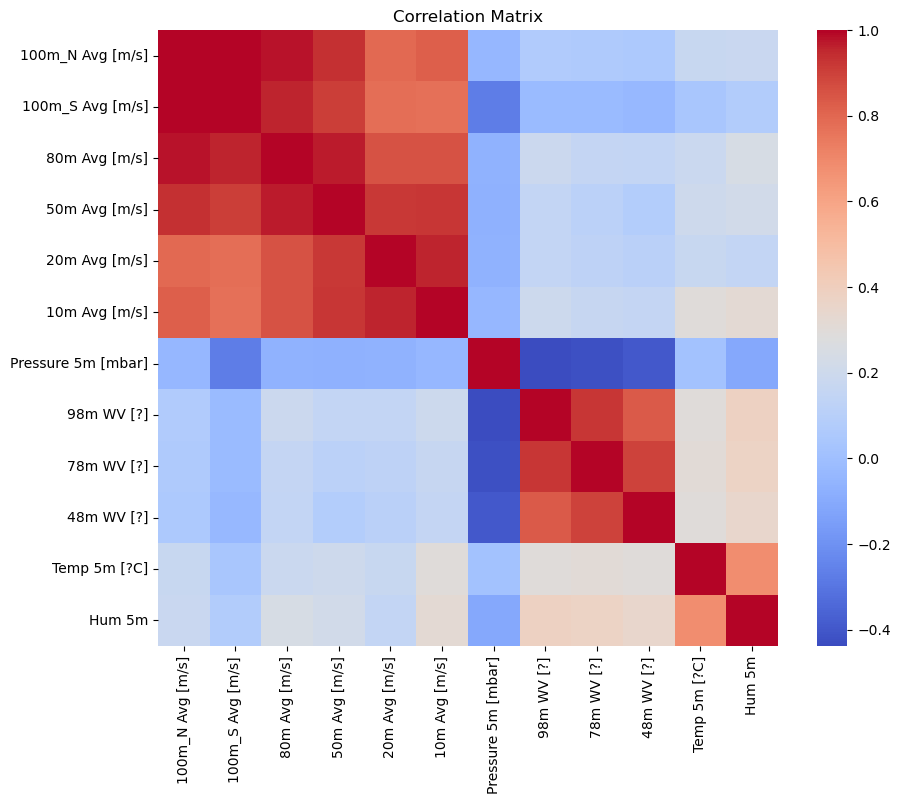

In [4]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [5]:
X = df[['50m Avg [m/s]']]

y = df['100m_N Avg [m/s]']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [8]:
print(y.isnull().sum())

59


In [10]:
print(y.name)

100m_N Avg [m/s]


In [11]:
df = df.dropna()

In [12]:
X = df[['50m Avg [m/s]']]

y = df['100m_N Avg [m/s]']

In [13]:
print(y.isnull().sum())

0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [16]:
print("Missing in X:")
print(X.isnull().sum())

print("Missing in y:")
print(y.isnull().sum())

Missing in X:
50m Avg [m/s]    0
dtype: int64
Missing in y:
0


In [17]:
y_pred = rf.predict(X_test)

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.9369095842535653
MSE : 1.5712183828746615
RMSE: 1.2534825020217322
R2 Score: 0.8276171737602694


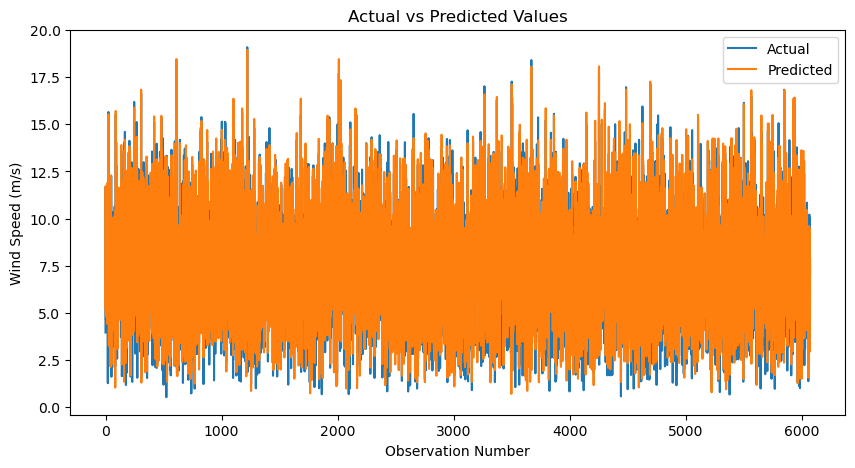

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('Observation Number')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.show()